In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt



ModuleNotFoundError: No module named 'torchvision'

# Dataset Description & Configuration

## Count Images per Class in Train / Validation / Test


In [3]:
DATASET_DIR = "dataset"   

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR = os.path.join(DATASET_DIR, "validation")
TEST_DIR = os.path.join(DATASET_DIR, "test")

selected_classes = [
    "Apple",
    "Banana",
    "Bell Pepper",
    "Carrot",
    "Grapes",
    "Kiwi",
    "Lemon",
    "Orange",
    "Pear",
    "Tomato"
]

# =========================
# 3. Function to count images
# =========================

def count_images_in_class(folder_path, class_name):
    class_path = os.path.join(folder_path, class_name)

    if not os.path.exists(class_path):
        print(f"Warning: Folder not found -> {class_path}")
        return 0

    valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

    image_count = len([
        file for file in os.listdir(class_path)
        if file.lower().endswith(valid_extensions)
    ])

    return image_count

# =========================
# 4. Count images for each split
# =========================

data = []

for class_name in selected_classes:
    train_count = count_images_in_class(TRAIN_DIR, class_name)
    val_count = count_images_in_class(VAL_DIR, class_name)
    test_count = count_images_in_class(TEST_DIR, class_name)

    data.append({
        "Class": class_name,
        "Train": train_count,
        "Validation": val_count,
        "Test": test_count,
        "Total": train_count + val_count + test_count
    })

df_counts = pd.DataFrame(data)

# Display table
df_counts

,Class,Train,Validation,Test,Total
0,Apple,68,10,10,88
1,Banana,75,9,9,93
2,Bell Pepper,90,9,10,109
3,Carrot,82,9,10,101
4,Grapes,100,9,10,119
5,Kiwi,88,10,10,108
6,Lemon,82,10,10,102
7,Orange,69,9,10,88
8,Pear,89,10,10,109
9,Tomato,92,10,10,112


## Plot class distribution

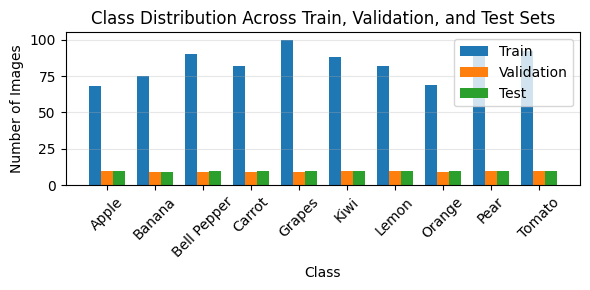

In [4]:
plt.figure(figsize=(6,3))

x = range(len(df_counts["Class"]))

plt.bar([i - 0.25 for i in x], df_counts["Train"], width=0.25, label="Train")
plt.bar(x, df_counts["Validation"], width=0.25, label="Validation")
plt.bar([i + 0.25 for i in x], df_counts["Test"], width=0.25, label="Test")

plt.title("Class Distribution Across Train, Validation, and Test Sets")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(x, df_counts["Class"], rotation=45)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

A grouped bar chart was created to compare the class distribution across the three splits. This helps identify whether the dataset is balanced or imbalanced.

If the number of samples is similar across classes, accuracy can be a reasonable evaluation metric. However, if some classes have many more images than others, accuracy may become misleading.

## Resize Images to 128×128 and Standardize to RGB 🖼️

In [5]:
import os
from PIL import Image

IMAGE_SIZE = (128, 128)
valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

def process_and_replace_image(image_path):
    with Image.open(image_path) as img:
        img = img.convert("RGB")
        img = img.resize(IMAGE_SIZE)

        # Save back to the same file
        img.save(image_path)

for split in ["train", "validation", "test"]:
    for class_name in selected_classes:
        folder_path = os.path.join(DATASET_DIR, split, class_name)

        for file_name in os.listdir(folder_path):
            if file_name.lower().endswith(valid_extensions):
                image_path = os.path.join(folder_path, file_name)

                try:
                    process_and_replace_image(image_path)
                except Exception as e:
                    print("Error:", image_path, e)

print("All images were converted to RGB and resized to 128×128 successfully.")

All images were converted to RGB and resized to 128×128 successfully.


In [6]:
# =========================
# 4. Display sample processed images
# =========================

plt.figure(figsize=(10, 4))

for i, class_name in enumerate(selected_classes[:5]):
    class_path = os.path.join(TRAIN_DIR, class_name)
    
    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(valid_extensions)
    ]
    
    sample_image_path = os.path.join(class_path, image_files[0])
    processed_image = load_and_preprocess_image(sample_image_path)
    
    plt.subplot(1, 5, i + 1)
    plt.imshow(processed_image)
    plt.title(class_name)
    plt.axis("off")

plt.suptitle("Sample Images After RGB Standardization and 128×128 Resizing")
plt.tight_layout()
plt.show()

NameError: name 'load_and_preprocess_image' is not defined

<Figure size 1000x400 with 0 Axes>

# Statistical EDA and Preprocessing

## Color Distribution Analysis

In [ ]:
# Step 3: Color Distribution Analysis

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from itertools import combinations

# =========================
# 1. Dataset path
# =========================

DATASET_DIR = "dataset"   # Change if needed

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR = os.path.join(DATASET_DIR, "validation")
TEST_DIR = os.path.join(DATASET_DIR, "test")

selected_classes = [
    "Apple",
    "Banana",
    "Bell Pepper",
    "Carrot",
    "Grapes",
    "Kiwi",
    "Lemon",
    "Orange",
    "Pear",
    "Tomato"
]

valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

# =========================
# 2. Function to calculate RGB mean per class
# =========================

def calculate_class_rgb_mean(split_dir, class_name, image_size=(128, 128)):
    class_path = os.path.join(split_dir, class_name)

    rgb_means = []

    for file_name in os.listdir(class_path):
        if file_name.lower().endswith(valid_extensions):
            image_path = os.path.join(class_path, file_name)

            img = Image.open(image_path).convert("RGB")
            img = img.resize(image_size)

            img_array = np.array(img) / 255.0

            mean_rgb = img_array.mean(axis=(0, 1))
            rgb_means.append(mean_rgb)

    rgb_means = np.array(rgb_means)

    return rgb_means.mean(axis=0)

# =========================
# 3. Calculate RGB mean using Training Set only
# =========================

rgb_data = []

for class_name in selected_classes:
    mean_r, mean_g, mean_b = calculate_class_rgb_mean(TRAIN_DIR, class_name)

    rgb_data.append({
        "Class": class_name,
        "Mean_R": mean_r,
        "Mean_G": mean_g,
        "Mean_B": mean_b
    })

df_rgb = pd.DataFrame(rgb_data)

df_rgb

,Class,Mean_R,Mean_G,Mean_B
0,Apple,0.647162,0.538919,0.457536
1,Banana,0.767881,0.716966,0.487291
2,Bell Pepper,0.596510,0.541474,0.353612
3,Carrot,0.737594,0.605893,0.481467
4,Grapes,0.547595,0.551987,0.427816
5,Kiwi,0.676310,0.678734,0.481183
6,Lemon,0.740244,0.694573,0.426987
7,Orange,0.709965,0.547226,0.306262
8,Pear,0.693735,0.677304,0.500375
9,Tomato,0.605592,0.444423,0.318377


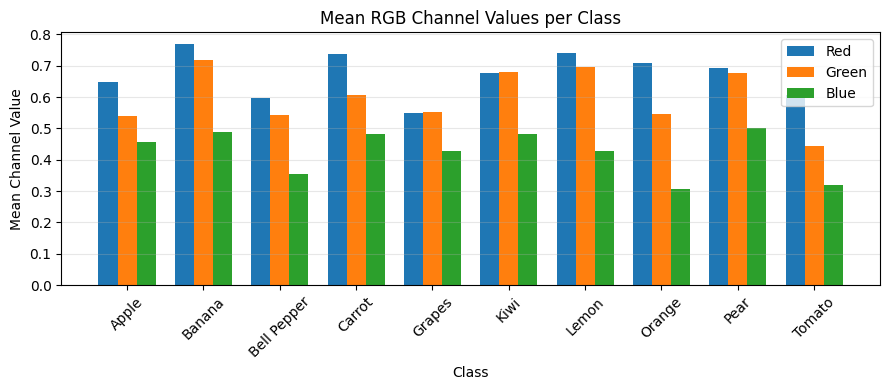

In [ ]:
# =========================
# 4. Grouped RGB bar chart
# =========================

plt.figure(figsize=(9, 4))

x = np.arange(len(df_rgb["Class"]))
width = 0.25

plt.bar(x - width, df_rgb["Mean_R"], width, label="Red")
plt.bar(x, df_rgb["Mean_G"], width, label="Green")
plt.bar(x + width, df_rgb["Mean_B"], width, label="Blue")

plt.title("Mean RGB Channel Values per Class")
plt.xlabel("Class")
plt.ylabel("Mean Channel Value")
plt.xticks(x, df_rgb["Class"], rotation=45)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

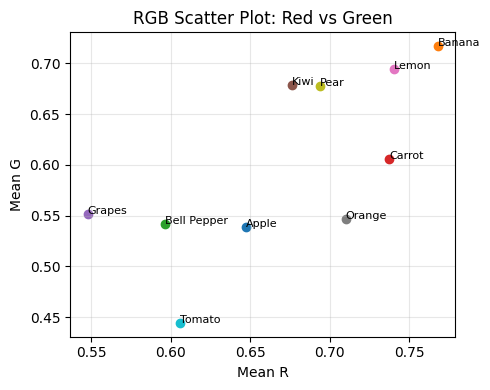

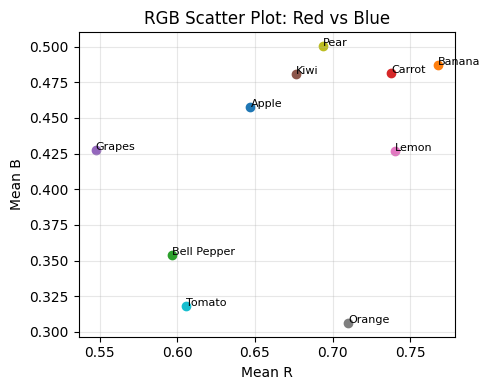

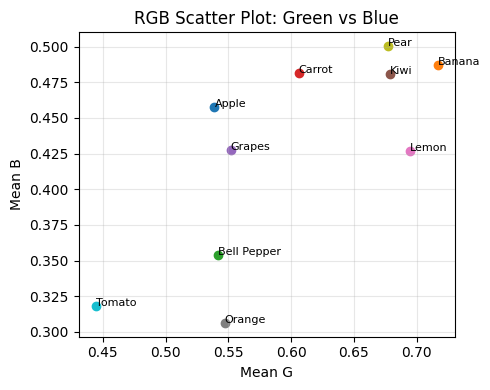

In [ ]:
# =========================
# Pairwise RGB scatter plots
# =========================

rgb_pairs = [
    ("Mean_R", "Mean_G", "Red vs Green"),
    ("Mean_R", "Mean_B", "Red vs Blue"),
    ("Mean_G", "Mean_B", "Green vs Blue")
]

for x_col, y_col, title in rgb_pairs:
    plt.figure(figsize=(5, 4))

    for _, row in df_rgb.iterrows():
        plt.scatter(row[x_col], row[y_col])
        plt.text(row[x_col], row[y_col], row["Class"], fontsize=8)

    plt.title(f"RGB Scatter Plot: {title}")
    plt.xlabel(x_col.replace("Mean_", "Mean "))
    plt.ylabel(y_col.replace("Mean_", "Mean "))
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

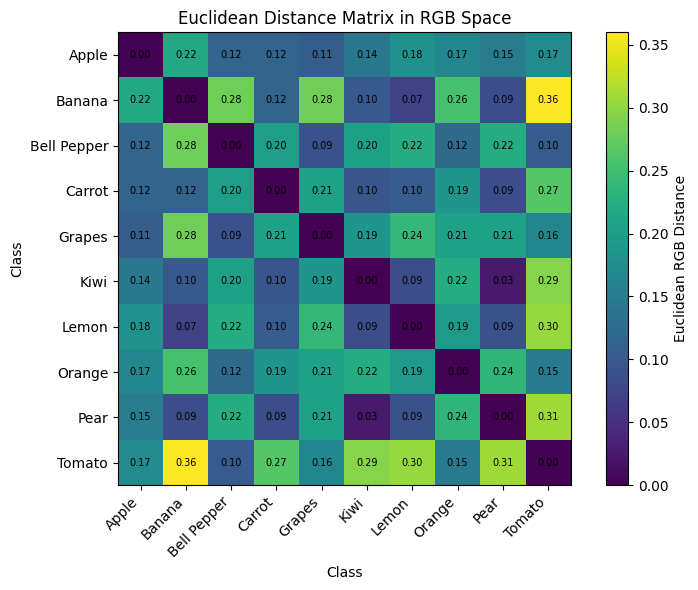

In [ ]:
# Clean heatmap code

plt.figure(figsize=(8, 6))

plt.imshow(df_distance, cmap="viridis")
plt.colorbar(label="Euclidean RGB Distance")

plt.title("Euclidean Distance Matrix in RGB Space")
plt.xlabel("Class")
plt.ylabel("Class")

plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, f"{distance_matrix[i, j]:.2f}",
                 ha="center", va="center", fontsize=7)

plt.tight_layout()
plt.show()

In [ ]:
# =========================
# 8. Find 3 class pairs with highest confusion risk
# =========================
# Small RGB distance = similar color = higher confusion risk

pair_distances = []

for i, j in combinations(range(len(class_names)), 2):
    pair_distances.append({
        "Class 1": class_names[i],
        "Class 2": class_names[j],
        "RGB Distance": distance_matrix[i, j]
    })

df_pair_distances = pd.DataFrame(pair_distances)

df_confusion_risk = df_pair_distances.sort_values(
    by="RGB Distance",
    ascending=True
).head(3)

df_confusion_risk

,Class 1,Class 2,RGB Distance
37,Kiwi,Pear,0.026158
13,Banana,Lemon,0.069988
15,Banana,Pear,0.085772


In this step, the average RGB color values were calculated for each selected class using only the training set. The grouped RGB bar chart shows how the red, green, and blue channel values differ between fruit and vegetable classes.

The RGB scatter plots help visualize whether classes form separate color clusters or overlap in color space. Classes that appear close together in these scatter plots may be more difficult for the CNN to distinguish using color alone.

The Euclidean distance matrix was also calculated in RGB space. A smaller distance between two classes means their average colors are more similar. Therefore, the three class pairs with the smallest RGB distances are considered the highest-risk pairs for possible confusion.

Later, these predicted high-risk pairs will be compared with the model’s actual confusion matrix to evaluate whether the initial EDA color analysis correctly predicted the model’s mistakes. 🎯

## Global Normalization ⚖️🖼️

In [ ]:
import os
import numpy as np
from PIL import Image

valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

# =========================
# 1. Calculate mean and std from TRAIN set only
# =========================

train_dir = os.path.join(DATASET_DIR, "train")

pixel_sum = np.zeros(3)
pixel_squared_sum = np.zeros(3)
total_pixels = 0

for class_name in selected_classes:
    folder_path = os.path.join(train_dir, class_name)

    for file_name in os.listdir(folder_path):
        if file_name.lower().endswith(valid_extensions):
            image_path = os.path.join(folder_path, file_name)

            with Image.open(image_path) as img:
                img = img.convert("RGB")
                img = img.resize((128, 128))   # safety check
                img_array = np.array(img).astype(np.float32) / 255.0

            pixel_sum += img_array.sum(axis=(0, 1))
            pixel_squared_sum += (img_array ** 2).sum(axis=(0, 1))
            total_pixels += img_array.shape[0] * img_array.shape[1]

train_mean = pixel_sum / total_pixels
train_std = np.sqrt((pixel_squared_sum / total_pixels) - (train_mean ** 2))

print("Training Mean RGB:")
print(f"R: {train_mean[0]:.4f}")
print(f"G: {train_mean[1]:.4f}")
print(f"B: {train_mean[2]:.4f}")

print("\nTraining Standard Deviation RGB:")
print(f"R: {train_std[0]:.4f}")
print(f"G: {train_std[1]:.4f}")
print(f"B: {train_std[2]:.4f}")

Training Mean RGB:
R: 0.6673
G: 0.5984
B: 0.4240

Training Standard Deviation RGB:
R: 0.3091
G: 0.3080
B: 0.3593


In [ ]:
# =========================
# Normalize one sample image as an example
# =========================

sample_class = selected_classes[0]
sample_folder = os.path.join(DATASET_DIR, "train", sample_class)

sample_file = [
    file for file in os.listdir(sample_folder)
    if file.lower().endswith(valid_extensions)
][0]

sample_path = os.path.join(sample_folder, sample_file)

image = Image.open(sample_path).convert("RGB")
image_array = np.array(image).astype(np.float32) / 255.0

normalized_image = (image_array - train_mean) / train_std

print("Original image shape:", image_array.shape)
print("Normalized image shape:", normalized_image.shape)

print("\nOriginal pixel range:")
print("Min:", image_array.min())
print("Max:", image_array.max())

print("\nNormalized pixel range:")
print("Min:", normalized_image.min())
print("Max:", normalized_image.max())

Original image shape: (128, 128, 3)
Normalized image shape: (128, 128, 3)

Original pixel range:
Min: 0.0
Max: 1.0

Normalized pixel range:
Min: -1.8502092082948198
Max: 1.6725414296490684


In [ ]:
# =========================
# 2. Function to apply Z-score normalization
# =========================

def load_normalized_image(image_path, mean, std):
    with Image.open(image_path) as img:
        img = img.convert("RGB")
        img = img.resize((128, 128))   # safety check
        img_array = np.array(img).astype(np.float32) / 255.0

    normalized_image = (img_array - mean) / std
    return normalized_image

In [ ]:
# =========================
# 3. Test normalization on all splits without storing all images
# =========================

for split in ["train", "validation", "test"]:
    print(f"\nChecking normalization for {split} set...")

    image_count = 0

    for class_name in selected_classes:
        folder_path = os.path.join(DATASET_DIR, split, class_name)

        for file_name in os.listdir(folder_path):
            if file_name.lower().endswith(valid_extensions):
                image_path = os.path.join(folder_path, file_name)

                normalized_image = load_normalized_image(
                    image_path,
                    train_mean,
                    train_std
                )

                image_count += 1

    print(f"{split} set normalized successfully.")
    print(f"Number of images checked: {image_count}")
    print(f"Example normalized image shape: {normalized_image.shape}")


Checking normalization for train set...
train set normalized successfully.
Number of images checked: 835
Example normalized image shape: (128, 128, 3)

Checking normalization for validation set...
validation set normalized successfully.
Number of images checked: 95
Example normalized image shape: (128, 128, 3)

Checking normalization for test set...
test set normalized successfully.
Number of images checked: 99
Example normalized image shape: (128, 128, 3)


The mean and standard deviation for the Red, Green, and Blue channels were calculated using only the training set. These values were then used to apply Z-score normalization to the Train, Validation, and Test sets.

The normalization formula is:

X normalized  =   x−μ   /  σ
	​

    
The Test Set was not used to calculate the normalization statistics because this would cause data leakage. The Test Set must represent unseen data, so using its pixel statistics during preprocessing would give indirect information about the evaluation data. Therefore, only Training Set statistics were used

## Training-Only Data Augmentation Pipeline 🔄🖼️

In [12]:
import os
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance, ImageDraw

train_dir = os.path.join(DATASET_DIR, "train")
valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

def augment_image(image, i):
    image = image.convert("RGB")

    # Rotation: fixed different angles
    angles = [-15, -8, 5, 10, 15]
    image = image.rotate(angles[i % 5])

    # Horizontal flip for some images
    if i % 2 == 0:
        image = image.transpose(Image.FLIP_LEFT_RIGHT)

    # Brightness change
    brightness_values = [0.8, 0.9, 1.1, 1.2, 1.0]
    image = ImageEnhance.Brightness(image).enhance(brightness_values[i % 5])

    # Contrast change
    contrast_values = [1.2, 1.1, 0.9, 0.8, 1.0]
    image = ImageEnhance.Contrast(image).enhance(contrast_values[i % 5])

    # Cutout
    draw = ImageDraw.Draw(image)
    x = 20 + i * 10
    y = 25 + i * 8
    draw.rectangle([x, y, x + 25, y + 25], fill=(0, 0, 0))

    return image



sample_images = []
sample_labels = []

for class_name in selected_classes:
    folder_path = os.path.join(train_dir, class_name)

    image_files = [
        file for file in os.listdir(folder_path)
        if file.lower().endswith(valid_extensions)
    ]

    image_path = os.path.join(folder_path, image_files[0])
    image = Image.open(image_path).convert("RGB")

    sample_images.append(image)
    sample_labels.append(class_name)

    if len(sample_images) == 5:
        break

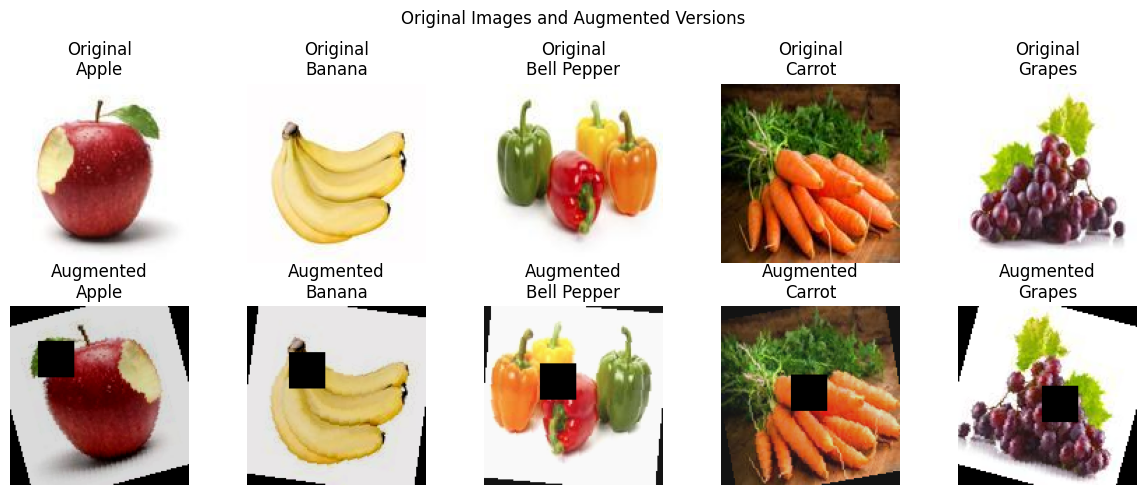

In [13]:
plt.figure(figsize=(12, 5))

for i in range(5):
    original_image = sample_images[i]
    augmented_image = augment_image(original_image, i)

    plt.subplot(2, 5, i + 1)
    plt.imshow(original_image)
    plt.title(f"Original\n{sample_labels[i]}")
    plt.axis("off")

    plt.subplot(2, 5, i + 6)
    plt.imshow(augmented_image)
    plt.title(f"Augmented\n{sample_labels[i]}")
    plt.axis("off")

plt.suptitle("Original Images and Augmented Versions")
plt.tight_layout()
plt.show()

A training-only data augmentation pipeline was created to improve model robustness and reduce overfitting. The pipeline includes random rotation up to 15 degrees, random horizontal flipping, brightness and contrast jitter, and optional cutout using random erasing.

These transformations are applied only to the training set. Validation and test images are not augmented because they must represent real unseen data. This keeps the evaluation fair and prevents artificial changes from affecting validation or test results.